# SPRINT 1: DATA EXPLORATION AND RESEARCH QUESTIONS

OBJETIVOS:

1. Cargar el dataset: código facilitado
2. Explorar el dataset: código facilitado
3. Normalizar la información: completar código
4. Plantear preguntas de investigación relevantes relacionadas con el aprendizaje no supervisado: completar texto
5. Reflexión final sobre técnicas de reducción de datos: completar texto





In [2]:
# import some libraries
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

# seaborn is a layer on top of matplotlib which has additional visualizations -
# just importing it changes the look of the standard matplotlib plots.
# the current version also shows some warnings which we'll disable.
import seaborn as sns
sns.set(style="white", color_codes=True)
import warnings
warnings.filterwarnings("ignore")

# show plots inline
%matplotlib inline

## 1.- Load Data





In [3]:
# get data and show some records

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data"
# load dataset into Pandas DataFrame
data = pd.read_csv(url, names=['sepal length','sepal width','petal length','petal width','target'])


#data = data.drop('Id', axis=1) # get rid of the Id column - don't need it
data.sample(5)

,sepal length,sepal width,petal length,petal width,target
7,5.0,3.4,1.5,0.2,Iris-setosa
45,4.8,3.0,1.4,0.3,Iris-setosa
49,5.0,3.3,1.4,0.2,Iris-setosa
59,5.2,2.7,3.9,1.4,Iris-versicolor
141,6.9,3.1,5.1,2.3,Iris-virginica


## 2a.- Explore Data

In [5]:
# split data into features (X) and labels (y)
X = data.iloc[:,0:4]
y = data.iloc[:,-1]

print("\n Caracteristicas \n")
print(X.sample(5))
print("\n Target \n")
print(y.sample(5))


 Caracteristicas 

     sepal length  sepal width  petal length  petal width
40            5.0          3.5           1.3          0.3
94            5.6          2.7           4.2          1.3
67            5.8          2.7           4.1          1.0
102           7.1          3.0           5.9          2.1
13            4.3          3.0           1.1          0.1

 Target 

25         Iris-setosa
108     Iris-virginica
142     Iris-virginica
122     Iris-virginica
74     Iris-versicolor
Name: target, dtype: object


## 2b.- Visualize Data


In [6]:
data["target"].value_counts()


,count
target,
Iris-setosa,50
Iris-versicolor,50
Iris-virginica,50


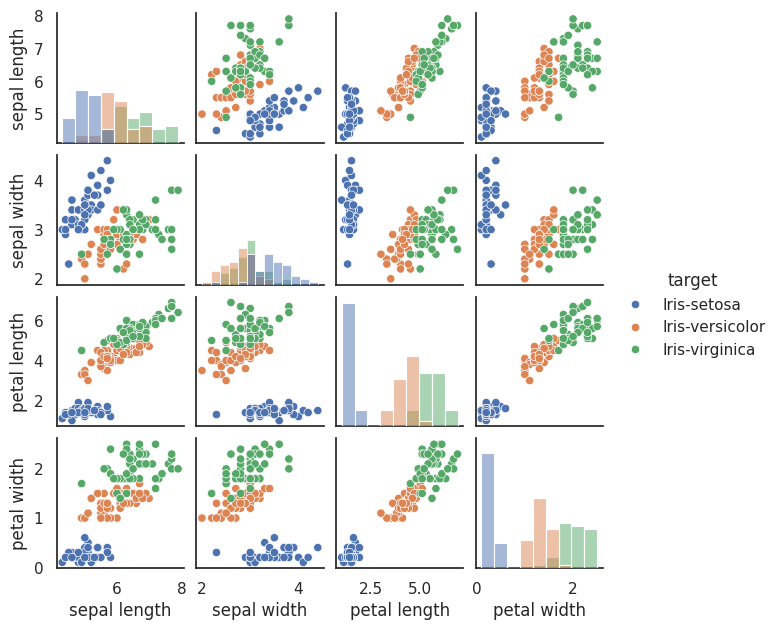

In [7]:
sns.pairplot(data, hue="target", diag_kind="hist", size=1.6);


Versicolor y Virginica son muy similares, sera muy dificil generar un algoritmo de clustering que las pueda separar, pero vamos a intentarlo!!



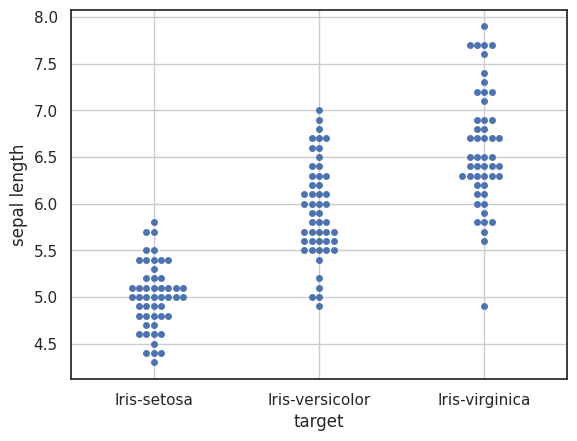

In [8]:
sns.swarmplot(x="target", y="sepal length", data=data)
plt.grid()

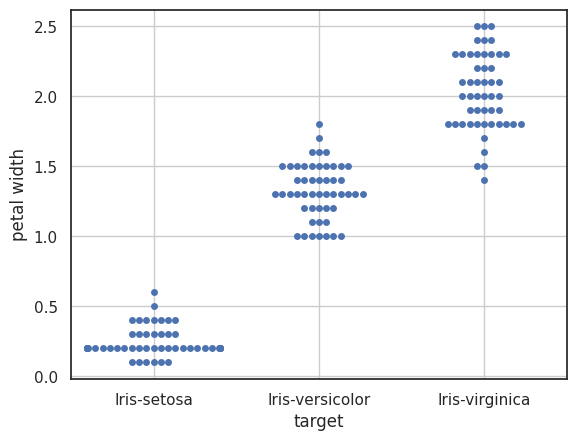

In [ ]:
sns.swarmplot(x="target", y="petal width", data=data)
plt.grid()

## 3.- Feature Scaling
Los datos estan desbalanceados por ejemplo Sepal Lenght es aproximadamente 4 veces mas grande que Petal Width, por lo tando recomiendo escalar los valores. de lo contrario, las características más grandes dominarán a las demás en la agrupación, etc.

In [9]:
from sklearn import preprocessing

scaler = preprocessing.StandardScaler()

X_scaled_array = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled_array, columns = X.columns)

X_scaled.sample(5)

,sepal length,sepal width,petal length,petal width
77,1.038005,-0.124958,0.705893,0.659118
82,-0.052506,-0.819166,0.080370,0.001753
84,-0.537178,-0.124958,0.421564,0.396172
133,0.553333,-0.587764,0.762759,0.396172
102,1.522676,-0.124958,1.217684,1.185010


##4.- Research questions

--------------------------------------------------------------------
INCORPORA AQUI LAS PREGUNTAS DE INVESTIGACIÓN

--------------------------------------------------------------------

* ¿Qué relación hay entre longitud y anchura de pétalos y sépalos? (Asociación)
* ¿Existe alguna relación entre el tamaño de los sépalos y los pétalos? (Asociación)
* ¿Qué posibles conjuntos podemos agrupar en función de las características de los pétalos y los sépalos? (Agrupación)




## 5.- Reflexión final técnicas de reducción de dimensionalidad

---------------------------------------------------
INCORPORA AQUÍ TU REFLEXIÓN SOBRE ESTE PUNTO

----------------------------------------------------
Si analizamos los datos sin etiquetar tras el reescalado, vemos que algunas relaciones son claramente lineales, como el largo y ancho de los sépalos, u otras que aunque no sea tan claro, sí parecen tener cierta linealidad en su relación, como la longitud del pétalo y del sépalo. Otras, sin embargo, no parecen en absoluto lineales, como el ancho y largo del pétalo. 

Por tanto, para capturar estas relaciones, si pretendemos emplear una reducción de dimensionalidad, deberíamos emplear técnicas diferentes. Por ejemplo, para las relaciones lineales, PCA sería una buena opción, ya que permitiría agrupar dicha información en una menor cantidad de variables; mientras que para las no lineales, otros algoritmos no lineales, tales como t-SNE o UMAP, podrían ser más adecuados, o de lo contrario nos enfrentaríamos a una pérdida sustancial de información.

# SPRINT 2: CLUSTERING

OBJETIVOS:
1. Practicar método silueta
2. Practicar método del codo
3. Practicar modelo clustering k-means
4. Añadir conclusiones

## 1.- Silhouette

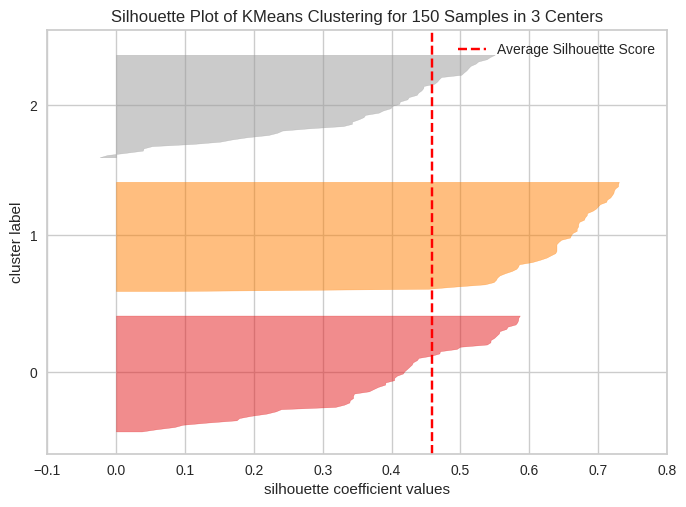

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 150 Samples in 3 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [ ]:
# Instantiate the clustering model and visualizer
#pip install yellowbrick

from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer

nclusters = 3
seed = 0

model = KMeans(n_clusters=nclusters
            , init = 'k-means++'
            , max_iter=500
            , n_init=10
            , random_state=seed)


visualizer = SilhouetteVisualizer(model)

visualizer.fit(X_scaled)    # Fit the data to the visualizer
visualizer.show()    # Draw/show/show the data

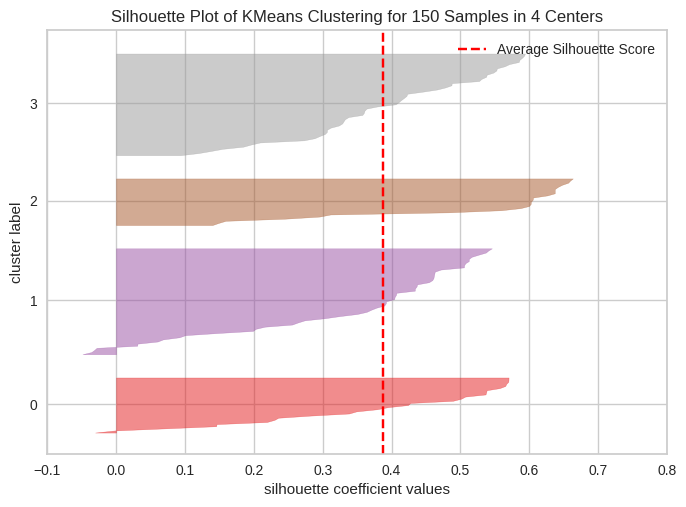

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 150 Samples in 4 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [ ]:
# Instantiate the clustering model and visualizer
#pip install yellowbrick


from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer

nclusters = 4
seed = 0

model = KMeans(n_clusters=nclusters
            , init = 'k-means++'
            , max_iter=500
            , n_init=10
            , random_state=seed)


visualizer = SilhouetteVisualizer(model)

visualizer.fit(X_scaled)    # Fit the data to the visualizer
visualizer.show()    # Draw/show/show the data

## 2.- Elbow

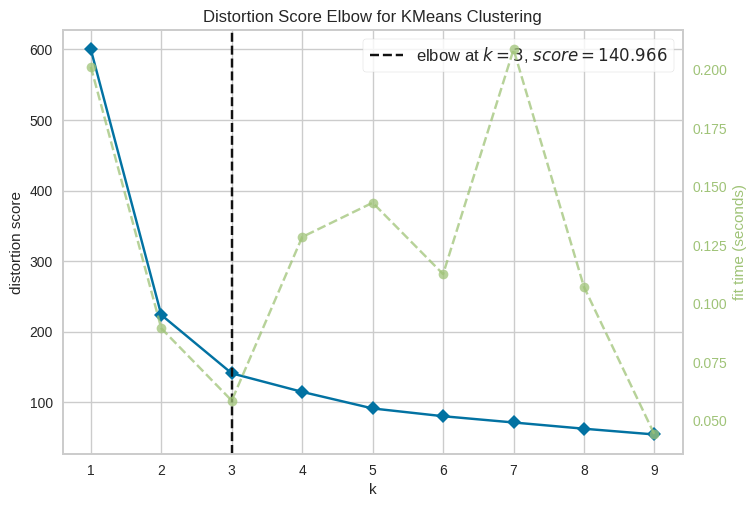

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [ ]:
#from sklearn import datasets
from yellowbrick.cluster import KElbowVisualizer

# Instantiate the clustering model and visualizer

seed = 0

km = KMeans(init = 'k-means++'
            , max_iter=500
            , n_init=10
            , random_state=seed)


visualizer = KElbowVisualizer(km, k=(1,10))

visualizer.fit(X_scaled)        # Fit the data to the visualizer
visualizer.show()               # Finalize and render the figure

## 3.- K-Means
Intente agrupar los datos en 4D y ver si puede reproducir los clústeres reales. Es decir, imagine que no tenemos las etiquetas de especies en estos datos y queremos dividir las flores en especies. podría establecer un número arbitrario de grupos e intentar dividirlos en grupos similares. Sabemos que hay 3 especies, así que encontremos 3 especies y veamos si las predicciones para cada punto coinciden con la etiqueta en y, por otro lado sabemos que por el metodo de las siluetas y elbow, la cantidad de clusters recomendada es 3

In [ ]:
from sklearn.cluster import KMeans

nclusters = 3
seed = 0

#DESARROLLE AQUI EL METODO DE KMeans utilizando la libreia KMeans.
#
#
#Complete aqui, llamando al metodo de K-means para entrenar el modelo utilizando las variables ncluster y seed
#Utilice X_Scaled para entrenar el modelo
#
#
#   km = KMeans(???)
#   km.fit(???)
#
#
#
#

# Ayuda
# Instancia del modelo K-Means
# km = KMeans(n_clusters=nclusters, random_state=seed)
# Entrenar el modelo utilizando las características escaladas (X_scaled)
# km.fit(X_scaled)


#FIN DE DESARROLLE AQUI EL METODO DE KMeans utilizando la libreia KMeans.

# Predecir el clúster al que pertenece cada punto de datos
y_cluster_kmeans = km.predict(X_scaled)

print("\n Caracteristicas \n")
print(X_scaled)

print("\n\n\n Clusters \n")
print(y_cluster_kmeans)


 Caracteristicas 

     sepal length  sepal width  petal length  petal width
0       -0.900681     1.032057     -1.341272    -1.312977
1       -1.143017    -0.124958     -1.341272    -1.312977
2       -1.385353     0.337848     -1.398138    -1.312977
3       -1.506521     0.106445     -1.284407    -1.312977
4       -1.021849     1.263460     -1.341272    -1.312977
..            ...          ...           ...          ...
145      1.038005    -0.124958      0.819624     1.447956
146      0.553333    -1.281972      0.705893     0.922064
147      0.795669    -0.124958      0.819624     1.053537
148      0.432165     0.800654      0.933356     1.447956
149      0.068662    -0.124958      0.762759     0.790591

[150 rows x 4 columns]



 Clusters 

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 0 0 0 2 0 0 0 0 0 0 0 0 2 0 0 0 0 2 0 0 0
 0 2 2 2 0 0 0 0 0 0 0 2 2 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 2 2 2 2 0 2 2 2 2
 2 2 0 0 2 2 2 2 0 2

## 4.- Investigación
Una vez que hayas aplicado técnicas de clustering al conjunto de datos, ¿cómo podrías evaluar si los clusters obtenidos son realmente representativos y bien formados? Investiga y describe métricas que permitan medir la calidad de los clusters, como la distancia intra-cluster (cohesión) y la distancia inter-cluster (separación). ¿Qué valores de estas métricas indicarían un buen resultado y por qué?

--------------------------------------------------------------
Añade aquí tus hallazgos


--------------------------------------------------------------